In [1]:
import pandas as pd
from datasets import load_from_disk, Audio

In [3]:
ds = load_from_disk("./afrispeech_arrow_16k")

Loading dataset from disk:   0%|          | 0/220 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/24 [00:00<?, ?it/s]

In [4]:
test_ds = ds["test"]

# 4. Quick checks
print(type(test_ds))
print(test_ds)

<class 'datasets.arrow_dataset.Dataset'>
Dataset({
    features: ['speaker_id', 'path', 'audio_id', 'audio', 'transcript', 'age_group', 'gender', 'accent', 'domain', 'country', 'duration'],
    num_rows: 6318
})


In [5]:
first_sample = test_ds[2]
print(type(first_sample))
print(first_sample.keys())
print(first_sample["domain"])
print(first_sample["country"])
print(first_sample["accent"])
print(first_sample["transcript"])

<class 'dict'>
dict_keys(['speaker_id', 'path', 'audio_id', 'audio', 'transcript', 'age_group', 'gender', 'accent', 'domain', 'country', 'duration'])
clinical
ZA
setswana
The short, mucus-secreting cells between the ciliated cells show bumpy microvilli on their surfaces.


In [5]:
def normalize_text(text: str) -> str:
    text = text.lower().strip()
    text = " ".join(text.split())
    return text

clinical_rows = []

for sample in test_ds:
    if sample["domain"] != "clinical":
        continue

    clinical_rows.append({
        "audio_id": sample["audio_id"],
        "speaker_id": sample["speaker_id"],
        "path": sample["path"],
        "transcript_raw": sample["transcript"],
        "transcript_norm": normalize_text(sample["transcript"]),
        "accent": sample["accent"],
        "country": sample["country"],
        "gender": sample["gender"],
        "age_group": sample["age_group"],
        "duration": sample["duration"],
        "sampling_rate": sample["audio"]["sampling_rate"],
    })

clinical_df = pd.DataFrame(clinical_rows)

print("Clinical rows:", len(clinical_df))
print("\nColumns:")
print(clinical_df.columns.tolist())
print("\nFirst 3 rows:")
print(clinical_df.head(3))

Clinical rows: 3606

Columns:
['audio_id', 'speaker_id', 'path', 'transcript_raw', 'transcript_norm', 'accent', 'country', 'gender', 'age_group', 'duration', 'sampling_rate']

First 3 rows:
                                            audio_id  \
0  27a83595-3d3f-4a6b-b909-7b8f364d736b/7cb8dfb31...   
1  80581f4f-9e72-48fb-b4c0-22e6972dbff3/95ddccb7b...   
2  13f2d282-bda1-4bc3-83b8-7a0d06e5eda0/933137f33...   

                         speaker_id  \
0  cdf91cf6e59ee411b985a40a955d4d1f   
1  6d53c4d9134a175a75a020155220ca7f   
2  6d53c4d9134a175a75a020155220ca7f   

                                                path  \
0  /home/ridwan/.cache/huggingface/datasets/downl...   
1  /home/ridwan/.cache/huggingface/datasets/downl...   
2  /home/ridwan/.cache/huggingface/datasets/downl...   

                                      transcript_raw  \
0  Protection of the host immune mechanism mighti...   
1  Ask the patient about allergies totape and ski...   
2  The short, mucus-secreting cells

In [6]:
print("Number of clinical samples:", len(clinical_df))
print("Number of unique speakers:", clinical_df["speaker_id"].nunique())
print("Number of unique countries:", clinical_df["country"].nunique())
print("Number of unique accents:", clinical_df["accent"].nunique())

Number of clinical samples: 3606
Number of unique speakers: 468
Number of unique countries: 10
Number of unique accents: 95


In [7]:
print(clinical_df["country"].value_counts())

country
NG    2855
KE     331
ZA     254
GH      76
BW      30
US      20
UG      19
RW      13
LS       4
ZW       4
Name: count, dtype: int64


In [8]:
print(clinical_df["accent"].value_counts().head(20))

accent
yoruba       269
swahili      225
igbo         193
hausa        144
english      103
anaang        97
mada          90
bini          86
ukwuani       79
zulu          78
mwaghavul     78
luhya         72
bajju         71
berom         62
ikulu         61
isizulu       60
eleme         60
brass         56
ekene         56
agatu         55
Name: count, dtype: int64


In [9]:
print(clinical_df["duration"].describe())

count    3606.000000
mean       10.530936
std        12.176854
min         1.000000
25%         5.000000
50%         8.000000
75%        12.482494
max       271.181000
Name: duration, dtype: float64


In [10]:
clinical_df.head()

,audio_id,speaker_id,path,transcript_raw,transcript_norm,accent,country,gender,age_group,duration,sampling_rate
0,27a83595-3d3f-4a6b-b909-7b8f364d736b/7cb8dfb31...,cdf91cf6e59ee411b985a40a955d4d1f,/home/ridwan/.cache/huggingface/datasets/downl...,Protection of the host immune mechanism mighti...,protection of the host immune mechanism mighti...,setswana,BW,Female,26-40,9.730000,16000
1,80581f4f-9e72-48fb-b4c0-22e6972dbff3/95ddccb7b...,6d53c4d9134a175a75a020155220ca7f,/home/ridwan/.cache/huggingface/datasets/downl...,Ask the patient about allergies totape and ski...,ask the patient about allergies totape and ski...,setswana,ZA,Female,19-25,4.526984,16000
2,13f2d282-bda1-4bc3-83b8-7a0d06e5eda0/933137f33...,6d53c4d9134a175a75a020155220ca7f,/home/ridwan/.cache/huggingface/datasets/downl...,"The short, mucus-secreting cells between the c...","the short, mucus-secreting cells between the c...",setswana,ZA,Female,19-25,8.563991,16000
3,99f6019b-4505-4c60-a462-79b0eb6e689a/2cb25e2dd...,38a2628beaa524416a8daf826e9d10e2,/home/ridwan/.cache/huggingface/datasets/downl...,Aspiration is terminated when aspirated materi...,aspiration is terminated when aspirated materi...,setswana,BW,Female,26-40,9.773991,16000
4,13600ba0-a4d5-46f7-9235-776cd60bfdee/1404f622c...,1e4033e1ce6f7cce51ca05b1908fc14a,/home/ridwan/.cache/huggingface/datasets/downl...,Identify the appropriate landmarks for the sit...,identify the appropriate landmarks for the sit...,setswana,BW,Female,19-25,6.258980,16000


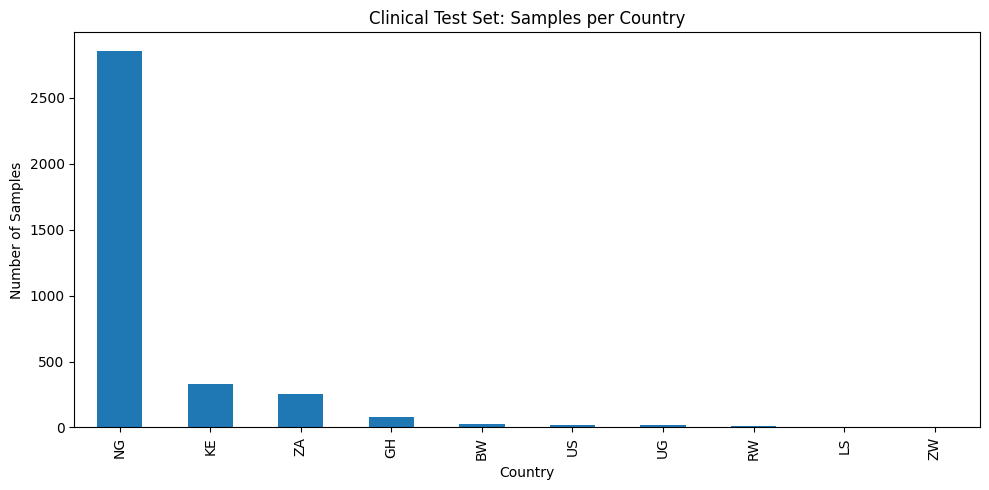

In [12]:
import matplotlib.pyplot as plt

country_counts = clinical_df["country"].value_counts()

plt.figure(figsize=(10, 5))
country_counts.plot(kind="bar")
plt.title("Clinical Test Set: Samples per Country")
plt.xlabel("Country")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

In [13]:
# Get balanced 100 samples per country

# Remove long clips
filtered_df = clinical_df[clinical_df["duration"] <= 30]

# Define groups
groups = ["NG", "KE", "ZA", "GH"]

samples_per_group = 20

subset_rows = []

for g in groups:
    group_df = filtered_df[filtered_df["country"] == g]
    sampled = group_df.sample(n=samples_per_group, random_state=42)
    subset_rows.append(sampled)

# Handle "Others"
others_df = filtered_df[~filtered_df["country"].isin(groups)]
others_sampled = others_df.sample(n=samples_per_group, random_state=42)

subset_rows.append(others_sampled)

eval_df = pd.concat(subset_rows).reset_index(drop=True)

print("Final subset size:", len(eval_df))
print(eval_df["country"].value_counts())

Final subset size: 100
country
NG    20
KE    20
ZA    20
GH    20
UG     5
US     5
BW     5
RW     3
LS     1
ZW     1
Name: count, dtype: int64


In [22]:
def assign_group(country):
    if country in ["NG", "KE", "ZA", "GH"]:
        return country
    else:
        return "Others"

eval_df["group"] = eval_df["country"].apply(assign_group)

print(eval_df["group"].value_counts())

group
NG        20
KE        20
ZA        20
GH        20
Others    20
Name: count, dtype: int64


In [23]:
# Save the eval_df
eval_df.to_csv("eval_df.csv", index=False)


In [24]:
import torch
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

asr = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-medium",
    device=device,
)

CUDA available: True
Device: 0
GPU: NVIDIA GeForce RTX 4090


Loading weights: 100%|██████████| 947/947 [00:00<00:00, 17515.49it/s]


In [25]:
sample_row = eval_df.iloc[0]
sample_audio_id = sample_row["audio_id"]

print("Audio ID:", sample_audio_id)
print("Country:", sample_row["country"])
print("Group:", sample_row["group"])
print("Reference:", sample_row["transcript_raw"])

Audio ID: a92586fb-0037-4df8-ab0b-46b1d35890b4/d84cb3435ea90487490c46682232f638
Country: NG
Group: NG
Reference: The family's wishes were honored and extensive efforts were made to arrange for the patient to be placed in a rehabilitation facility.


In [26]:
sample_match = None

for sample in test_ds:
    if sample["audio_id"] == sample_audio_id:
        sample_match = sample
        break

print(sample_match.keys())
print(sample_match["audio"].keys())
print("Sampling rate:", sample_match["audio"]["sampling_rate"])
print("Audio length:", len(sample_match["audio"]["array"]))

dict_keys(['speaker_id', 'path', 'audio_id', 'audio', 'transcript', 'age_group', 'gender', 'accent', 'domain', 'country', 'duration'])
dict_keys(['path', 'array', 'sampling_rate'])
Sampling rate: 16000
Audio length: 174912


In [28]:
audio_input = sample_match["audio"]

prediction = asr(audio_input)

print("Prediction object:")
print(prediction)

print("\nReference:")
print(sample_row["transcript_raw"])

print("\nPredicted:")
print(prediction["text"])

ValueError: When passing a dictionary to AutomaticSpeechRecognitionPipeline, the dict needs to contain a "raw" key containing the numpy array or torch tensor representing the audio and a "sampling_rate" key, containing the sampling_rate associated with that array

In [29]:
import pandas as pd
import re
from jiwer import wer, process_words

df = pd.read_csv("whisper_medium_clinical_predictions.csv")

# ── Fix 1: detect genuine OCR broken words ───────────────────────────────────
# Only flag words with NO vowels or merged lowercase runs without spaces
def has_genuine_ocr_errors(text):
    # Look for two lowercase words merged together - no space between them
    # Pattern: lowercase letter immediately followed by uppercase is fine
    # Pattern: word boundary missing e.g. "mightincrease"
    words = str(text).split()
    for word in words:
        word_clean = re.sub(r'[^a-zA-Z]', '', word)
        # Flag if word is very long AND not a known medical term pattern
        if len(word_clean) > 15 and word_clean.islower():
            return True
    return False

broken_real = df[df["reference"].apply(has_genuine_ocr_errors)]
print(f"Genuine OCR broken references: {len(broken_real)} / {len(df)}")

# ── Fix 2: clean predictions ─────────────────────────────────────────────────
def clean_prediction(text):
    text = str(text).lower()
    # Remove spoken punctuation
    text = re.sub(r'\bfull stop\b', '', text)
    text = re.sub(r'\bcomma\b', '', text)
    text = re.sub(r'\bperiod\b', '', text)
    text = re.sub(r'\bcolon\b', '', text)
    text = re.sub(r'\bsemicolon\b', '', text)
    text = re.sub(r'\bexclamation mark\b', '', text)
    text = re.sub(r'\bquestion mark\b', '', text)
    text = re.sub(r'\bnew line\b', '', text)
    text = re.sub(r'\bnext line\b', '', text)
    # Remove punctuation symbols
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_reference(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ── Fix 3: compute WER on clean set only ─────────────────────────────────────
# Exclude genuine OCR broken references from WER calculation
df_clean = df[~df["reference"].apply(has_genuine_ocr_errors)].copy()
print(f"Clean references remaining: {len(df_clean)} / {len(df)}")

references_clean  = [clean_reference(r) for r in df_clean["reference"].tolist()]
predictions_clean = [clean_prediction(p) for p in df_clean["prediction"].tolist()]

cleaned_wer = wer(references_clean, predictions_clean)
output      = process_words(references_clean, predictions_clean)

print(f"\n── WER on clean references ──────────────────")
print(f"WER:           {cleaned_wer:.3f}")
print(f"Substitutions: {output.substitutions}")
print(f"Deletions:     {output.deletions}")
print(f"Insertions:    {output.insertions}")
print(f"Hits:          {output.hits}")


Genuine OCR broken references: 156 / 3606
Clean references remaining: 3450 / 3606

── WER on clean references ──────────────────
WER:           0.410
Substitutions: 9606
Deletions:     1256
Insertions:    8747
Hits:          36953


In [ ]:
from transformers.models.whisper.english_normalizer import BasicTextNormalizer
import pandas as pd
from jiwer import wer

df = pd.read_csv("whisper_medium_clinical_predictions.csv")

normalizer = BasicTextNormalizer()

references_norm  = [normalizer(str(r)) for r in df["reference"].tolist()]
predictions_norm = [normalizer(str(p)) for p in df["prediction"].tolist()]

print(f"WER with Whisper normaliser: {wer(references_norm, predictions_norm):.3f}")

# Show a few examples of what the normaliser does
for i in range(3):
    print(f"\nOriginal ref:  {df['reference'].iloc[i]}")
    print(f"Normalised ref: {references_norm[i]}")
    print(f"Original pred:  {df['prediction'].iloc[i]}")
    print(f"Normalised pred: {predictions_norm[i]}")